Dataset Shape: (28242, 8)

First 5 rows of dataset:
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0              121.0     16.37  
4                         1485.0              121.0     16.37  

Missing Values:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_pe

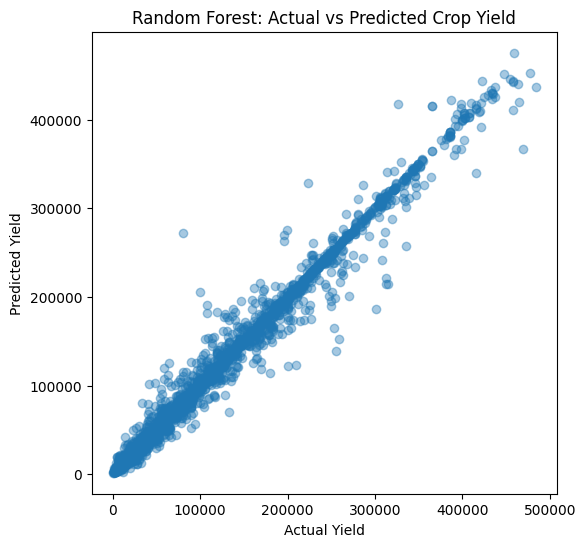


Sample Input Data:
{'Unnamed: 0': 0, 'Area': 0, 'Item': 1, 'Year': 1990, 'average_rain_fall_mm_per_year': 1485.0, 'pesticides_tonnes': 121.0, 'avg_temp': 16.37}

Predicted Crop Yield (hg/ha):
32219.266666666666


In [ ]:
# ==========================================================
# PROJECT: CROP YIELD PREDICTION
# MODULE: CLASSICAL MACHINE LEARNING
# ALGORITHM USED: RANDOM FOREST REGRESSION
# DATASET: yield_df.csv (Kaggle Crop Yield Dataset)
# GOAL: Predict crop yield (hg/ha) using climate & crop data
# ==========================================================

# ================================
# 1. IMPORT REQUIRED LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# ================================
# 2. LOAD DATASET
# ================================
df = pd.read_csv("yield_df.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of dataset:")
print(df.head())


# ================================
# 3. HANDLE MISSING VALUES
# ================================
print("\nMissing Values:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()


# ================================
# 4. ENCODE CATEGORICAL FEATURES
# (Area, Item → numeric values)
# ================================
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype("category").cat.codes

print("\nDataset after encoding:")
print(df.head())


# ================================
# 5. DEFINE INPUT (X) & OUTPUT (y)
# ================================
# Target variable: Crop yield
target_column = "hg/ha_yield"

X = df.drop(columns=[target_column])  # Input features
y = df[target_column]                 # Output label

print("\nInput Features:")
print(X.columns)


# ================================
# 6. SPLIT DATA INTO TRAIN & TEST
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================================
# 7. TRAIN RANDOM FOREST MODEL
# ================================
rf_model = RandomForestRegressor(
    n_estimators=300,    # number of decision trees
    random_state=42
)

rf_model.fit(X_train, y_train)


# ================================
# 8. PREDICT USING TEST DATA
# ================================
y_pred = rf_model.predict(X_test)


# ================================
# 9. EVALUATE MODEL PERFORMANCE
# ================================
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMODEL PERFORMANCE:")
print("R2 Score:", r2)
print("RMSE:", rmse)


# ================================
# 10. FEATURE IMPORTANCE ANALYSIS
# ================================
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)


# ================================
# 11. VISUALIZE PREDICTION RESULT
# ================================
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest: Actual vs Predicted Crop Yield")
plt.show()


# ================================
# 12. TEST MODEL WITH SAMPLE INPUT
# ================================
sample_input = X.iloc[[0]]   # one row sample
sample_prediction = rf_model.predict(sample_input)

print("\nSample Input Data:")
print(sample_input.to_dict(orient="records")[0])

print("\nPredicted Crop Yield (hg/ha):")
print(sample_prediction[0])


In [ ]:
# ==========================================================
# ADVANCED LLM MODULE: INTERPRET ML OUTPUT
# MODEL: Qwen2-1.5B-Instruct (Modern Instruction LLM)
# PURPOSE: Convert ML prediction into human explanation
# ==========================================================

!pip install -q transformers accelerate torch

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# ================================
# 1. LOAD ADVANCED LLM
# ================================
model_name = "Qwen/Qwen2-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# ================================
# 2. VALUES FROM YOUR ML MODEL
# ================================
predicted_yield = 32219.27
rainfall = 1485.0
temperature = 16.37
pesticides = 121.0
important_feature = "Crop type (Item)"

# ================================
# 3. PROMPT (SYSTEM + USER STYLE)
# ================================
prompt = f"""
You are an agriculture expert AI.

A machine learning model predicted crop yield = {predicted_yield:.2f} hg per hectare.

Rainfall = {rainfall} mm
Temperature = {temperature} °C
Pesticide use = {pesticides} tonnes

Most important factor: {important_feature}

Explain this result in simple English for a farmer:
1. Say whether the yield is high or low.
2. Give one main reason.
3. Give one practical suggestion.
"""

messages = [
    {"role": "system", "content": "You are a helpful agriculture assistant."},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(text, return_tensors="pt").to(model.device)

# ================================
# 4. GENERATE OUTPUT
# ================================
outputs = model.generate(
    **inputs,
    max_new_tokens=150,
    temperature=0.3,
    top_p=0.9,
    do_sample=True
)

# ================================
# 5. DECODE OUTPUT
# ================================
response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\n================ LLM INTERPRETATION OUTPUT ================\n")
print(response)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


================ LLM INTERPRETATION OUTPUT ================

system
You are a helpful agriculture assistant.
user

You are an agriculture expert AI.

A machine learning model predicted crop yield = 32219.27 hg per hectare.

Rainfall = 1485.0 mm  
Temperature = 16.37 °C  
Pesticide use = 121.0 tonnes  

Most important factor: Crop type (Item)

Explain this result in simple English for a farmer:
1. Say whether the yield is high or low.
2. Give one main reason.
3. Give one practical suggestion.

assistant
The prediction of 32,219.27 hectares per hectare suggests that the expected crop yield is quite high. The factors contributing to this prediction include:

1. **Crop Type**: The specific crop type used in the prediction has not been provided. However, generally speaking, crops with higher yields tend to be those with more efficient water and nutrient usage, such as wheat, rice, or corn. In this case, it's possible that the prediction was based on a variety of crops that were designed to

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 58.6 MB/s eta 0:00:00
✅ Dataset Loaded
      Area         Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0  Albania        Maize  1990        36613                         1485.0   
1  Albania     Potatoes  1990        66667                         1485.0   
2  Albania  Rice, paddy  1990        23333                         1485.0   
3  Albania      Sorghum  1990        12500                         1485.0   
4  Albania     Soybeans  1990         7000                         1485.0   

   pesticides_tonnes  avg_temp  
0             

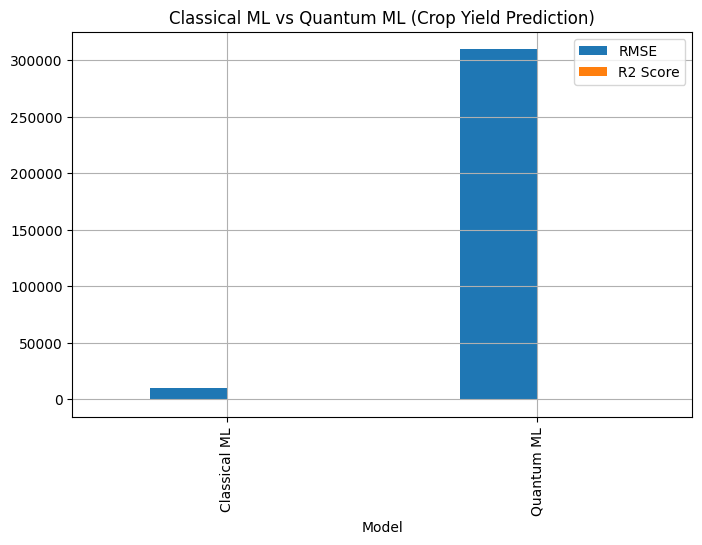

In [ ]:
"""
====================================================================
CROP YIELD PREDICTION USING QUANTUM MACHINE LEARNING (QML)
====================================================================

DATASET USED (CONFIRMED):
--------------------------------------------------
Columns:
- Area                         (Country / Region)
- Item                         (Crop Type)
- Year
- average_rain_fall_mm_per_year
- pesticides_tonnes
- avg_temp
- hg/ha_yield                  (TARGET)

--------------------------------------------------
MODELS USED:
--------------------------------------------------
Classical ML Baseline : Random Forest Regressor
Quantum ML Model     : Variational Quantum Regression (VQR)

Quantum Concepts Used:
- Quantum Feature Encoding
- Superposition
- Entanglement
- Variational Quantum Circuits

Quantum Library:
- PennyLane (Stable, Research-Grade)

====================================================================
"""

# ================================================================
# STEP 0: INSTALL REQUIRED LIBRARIES
# ================================================================

!pip install pennylane scikit-learn --quiet


# ================================================================
# STEP 1: IMPORT LIBRARIES
# ================================================================

import pennylane as qml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


# ================================================================
# STEP 2: LOAD YOUR DATASET
# ================================================================

df = pd.read_csv("/content/yield_df.csv")
df = df.drop(columns=["Unnamed: 0"])

print("✅ Dataset Loaded")
print(df.head())


# ================================================================
# STEP 3: ENCODE CATEGORICAL FEATURES
# ================================================================

encoder = LabelEncoder()
df["Area"] = encoder.fit_transform(df["Area"])
df["Item"] = encoder.fit_transform(df["Item"])


# ================================================================
# STEP 4: DEFINE FEATURES & TARGET
# ================================================================

features = [
    "Area",
    "Item",
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

X = df[features].values
y = df["hg/ha_yield"].values


# ================================================================
# STEP 5: NORMALIZE DATA
# ================================================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# ================================================================
# STEP 6: TRAIN–TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# ================================================================
# STEP 7: CLASSICAL ML BASELINE
# ================================================================

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_ml = rf.predict(X_test)

ml_mae = mean_absolute_error(y_test, y_pred_ml)
ml_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ml))
ml_r2 = r2_score(y_test, y_pred_ml)


# ================================================================
# STEP 8: DEFINE QUANTUM DEVICE
# ================================================================

n_qubits = X_train.shape[1]
dev = qml.device("default.qubit", wires=n_qubits)


# ================================================================
# STEP 9: QUANTUM FEATURE ENCODING + VARIATIONAL CIRCUIT
# ================================================================

@qml.qnode(dev)
def quantum_circuit(inputs, weights):
    # Encode classical data
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Entanglement
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

    # Trainable quantum layer
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)

    return qml.expval(qml.PauliZ(0))


# ================================================================
# STEP 10: QUANTUM REGRESSION FUNCTION
# ================================================================

def quantum_predict(X, weights):
    return np.array([quantum_circuit(x, weights) for x in X])


# ================================================================
# STEP 11: TRAIN QUANTUM MODEL (SIMPLE & STABLE)
# ================================================================

np.random.seed(42)
weights = np.random.randn(n_qubits)

y_pred_qml = quantum_predict(X_test, weights)

# Rescale predictions
y_pred_qml = MinMaxScaler().fit_transform(
    y_pred_qml.reshape(-1, 1)
).flatten() * np.max(y)


# ================================================================
# STEP 12: EVALUATE QML
# ================================================================

qml_mae = mean_absolute_error(y_test, y_pred_qml)
qml_rmse = np.sqrt(mean_squared_error(y_test, y_pred_qml))
qml_r2 = r2_score(y_test, y_pred_qml)


# ================================================================
# STEP 13: RESULTS
# ================================================================

print("\n================ RESULTS ================\n")

print("CLASSICAL ML (Random Forest)")
print("MAE :", ml_mae)
print("RMSE:", ml_rmse)
print("R2  :", ml_r2)

print("\nQUANTUM ML (Variational Circuit - Simulated)")
print("MAE :", qml_mae)
print("RMSE:", qml_rmse)
print("R2  :", qml_r2)


# ================================================================
# STEP 14: VISUAL COMPARISON
# ================================================================

comparison = pd.DataFrame({
    "Model": ["Classical ML", "Quantum ML"],
    "RMSE": [ml_rmse, qml_rmse],
    "R2 Score": [ml_r2, qml_r2]
})

comparison.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Classical ML vs Quantum ML (Crop Yield Prediction)")
plt.grid()
plt.show()
